In [1]:
import pandas as pd
import seaborn as sns
import matplotlib as plt
import numpy as np

In [2]:
ds = pd.read_csv("smartphone-usage-and-addiction-prediction/versions/1/Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")
ds = ds.drop(columns=["transaction_id","user_id"])
ds = pd.DataFrame(ds)
ds['addiction_level'] = ds['addiction_level'].fillna('None')
ds.head()

,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,None,0
1,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,None,0
2,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


In [3]:
from sklearn.preprocessing import OrdinalEncoder

In [4]:
cat_str = ['Other', 'Male', 'Female']
enc_gender = OrdinalEncoder(categories=[cat_str])
ds['gender'] = enc_gender.fit_transform(ds[['gender']])

cat_sa = ['Low', 'Medium', 'High']
enc_stress = OrdinalEncoder(categories=[cat_sa])
ds['stress_level'] = enc_stress.fit_transform(ds[['stress_level']])

cat_sb = ['No', 'Yes']
enc_academic = OrdinalEncoder(categories=[cat_sb])
ds['academic_work_impact'] = enc_academic.fit_transform(ds[['academic_work_impact']])

cat_sc = ['None', 'Mild', 'Moderate', 'Severe']
enc_addiction = OrdinalEncoder(categories=[cat_sc])
ds['addiction_level'] = enc_addiction.fit_transform(ds[['addiction_level']])

In [7]:
#data checking 
ds.info()
ds.describe()
ds.isnull().sum()
ds.corr()

<class 'pandas.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      7500 non-null   int64  
 1   gender                   7500 non-null   float64
 2   daily_screen_time_hours  7500 non-null   float64
 3   social_media_hours       7500 non-null   float64
 4   gaming_hours             7500 non-null   float64
 5   work_study_hours         7500 non-null   float64
 6   sleep_hours              7500 non-null   float64
 7   notifications_per_day    7500 non-null   int64  
 8   app_opens_per_day        7500 non-null   int64  
 9   weekend_screen_time      7500 non-null   float64
 10  stress_level             7500 non-null   float64
 11  academic_work_impact     7500 non-null   float64
 12  addiction_level          7500 non-null   float64
 13  addicted_label           7500 non-null   int64  
dtypes: float64(10), int64(4)
memory usa

,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
age,1.000000,-0.017495,0.012767,0.000342,-0.026107,-0.017147,-0.007462,0.000387,-0.002276,0.015286,0.000955,-0.014486,0.016373,0.004220
gender,-0.017495,1.000000,-0.006968,0.001151,0.004499,0.005200,0.025167,-0.003727,0.006357,-0.005832,-0.022342,0.002131,-0.008969,0.003499
daily_screen_time_hours,0.012767,-0.006968,1.000000,0.010321,0.001140,0.003108,0.019343,0.000811,0.024448,0.964295,0.013149,-0.003327,0.541402,0.577112
social_media_hours,0.000342,0.001151,0.010321,1.000000,-0.000902,-0.002580,0.005947,-0.008593,-0.000371,0.011404,-0.010770,0.006309,0.385985,0.414244
gaming_hours,-0.026107,0.004499,0.001140,-0.000902,1.000000,0.004384,-0.002874,0.015563,-0.009917,-0.006282,-0.001744,-0.004645,0.002222,0.008485
work_study_hours,-0.017147,0.005200,0.003108,-0.002580,0.004384,1.000000,-0.027150,-0.017518,-0.021676,0.004667,0.018259,-0.021702,0.000320,0.001103
sleep_hours,-0.007462,0.025167,0.019343,0.005947,-0.002874,-0.027150,1.000000,0.016273,0.005692,0.018933,-0.018851,-0.007841,0.032662,0.035496
notifications_per_day,0.000387,-0.003727,0.000811,-0.008593,0.015563,-0.017518,0.016273,1.000000,0.004598,-0.002199,-0.001932,0.005386,-0.007484,-0.000660
app_opens_per_day,-0.002276,0.006357,0.024448,-0.000371,-0.009917,-0.021676,0.005692,0.004598,1.000000,0.021069,-0.002314,-0.007385,0.011047,0.011041
weekend_screen_time,0.015286,-0.005832,0.964295,0.011404,-0.006282,0.004667,0.018933,-0.002199,0.021069,1.000000,0.011053,-0.005233,0.523358,0.555426


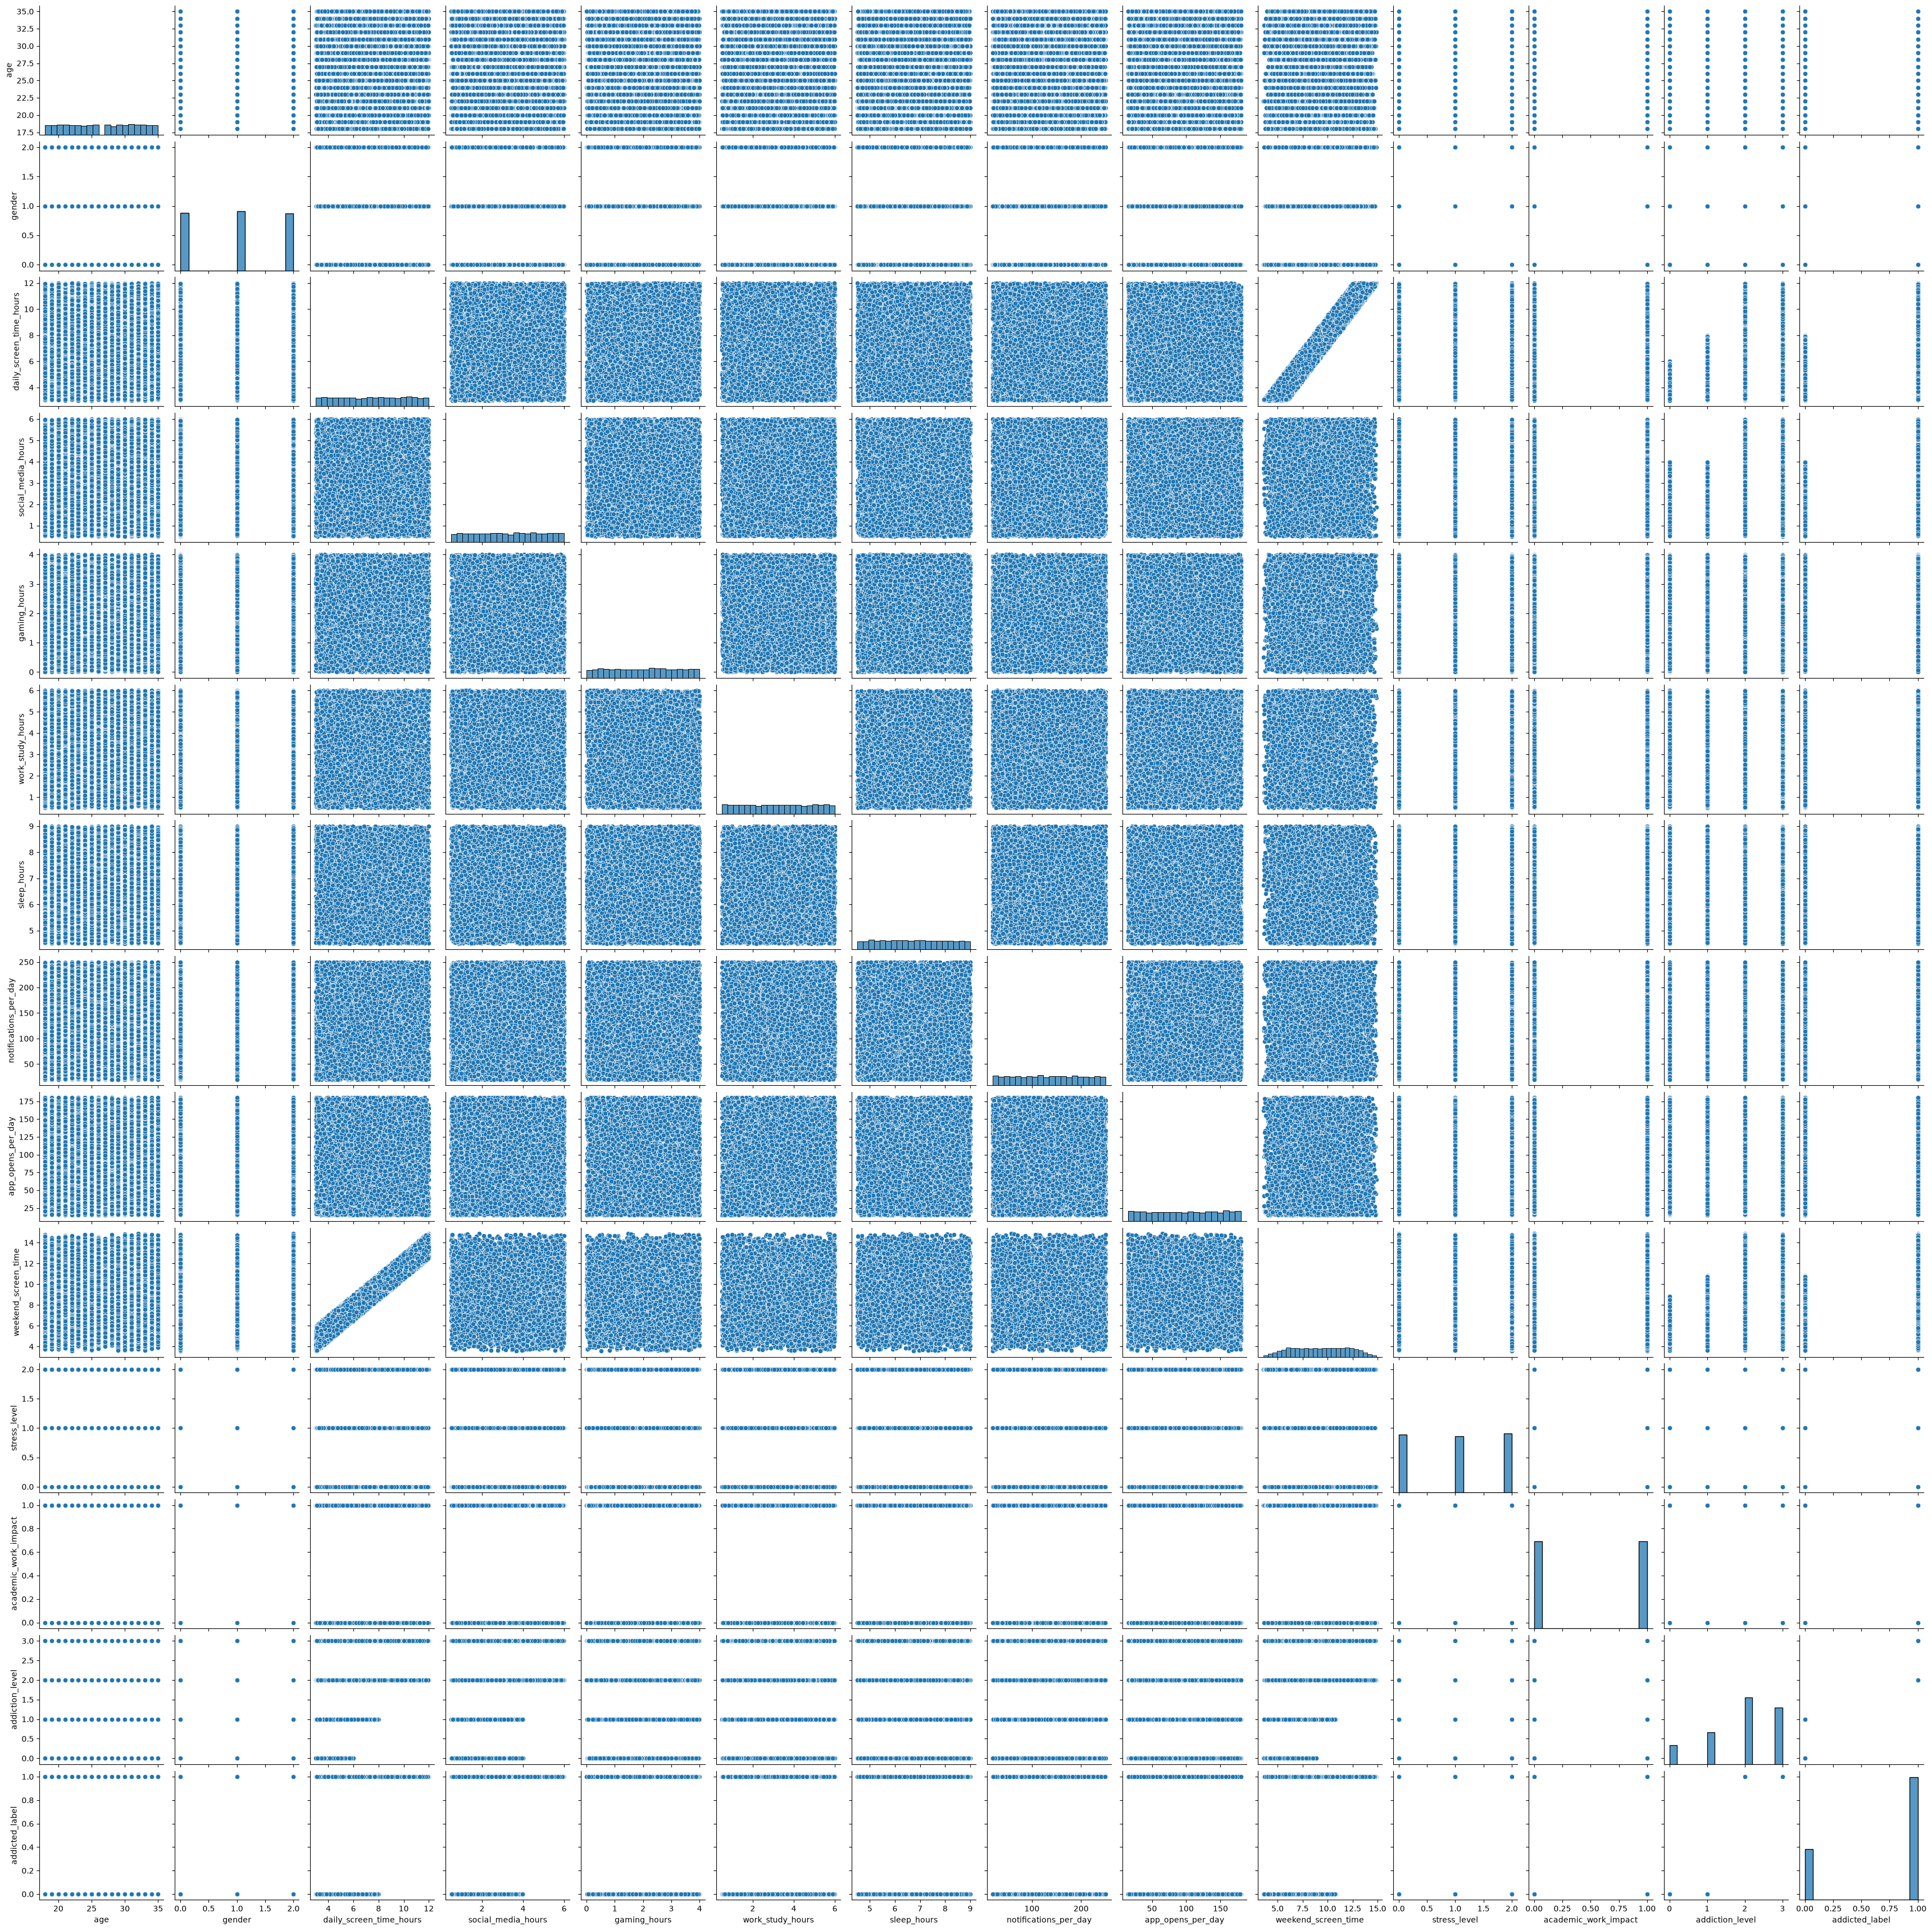

In [8]:
#ploting all the features
sns.pairplot(ds)

In [9]:
X = ds.drop(columns=["addiction_level","addicted_label"])
y = ds["addiction_level"]

In [10]:
#spliting the data in 80% adnd 20%
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [11]:
X_train.shape,X_test.shape

((6000, 12), (1500, 12))

In [12]:
#standardizing the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [13]:
import pickle
pickle.dump(scaler,open("scalling.pkl","wb"))

In [14]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
#importing libraries 
from sklearn.ensemble import RandomForestClassifier 

In [16]:
rf = RandomForestClassifier(random_state=42)

In [17]:
#searching for the best parameters 
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 20),
    'min_samples_split': randint(2, 15),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}
random_search = RandomizedSearchCV(
    estimator=rf,              # plain RandomForestClassifier here
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='f1_weighted',
    n_jobs=1,
    random_state=42,
    verbose=2
)
print("Best params:", random_search)


Best params: RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42),
                   n_jobs=1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x00000204C0691090>,
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x00000204C0639940>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x00000204C0691310>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x00000204C0659940>},
                   random_state=42, scoring='f1_weighted', verbose=2)


In [18]:
#training the model with the data
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END bootstrap=True, max_depth=17, max_features=None, min_samples_leaf=8, min_samples_split=14, n_estimators=120; total time=   4.2s
[CV] END bootstrap=True, max_depth=17, max_features=None, min_samples_leaf=8, min_samples_split=14, n_estimators=120; total time=   4.1s
[CV] END bootstrap=True, max_depth=17, max_features=None, min_samples_leaf=8, min_samples_split=14, n_estimators=120; total time=   4.1s
[CV] END bootstrap=True, max_depth=13, max_features=None, min_samples_leaf=8, min_samples_split=6, n_estimators=199; total time=   6.8s
[CV] END bootstrap=True, max_depth=13, max_features=None, min_samples_leaf=8, min_samples_split=6, n_estimators=199; total time=   6.9s
[CV] END bootstrap=True, max_depth=13, max_features=None, min_samples_leaf=8, min_samples_split=6, n_estimators=199; total time=   6.9s
[CV] END bootstrap=False, max_depth=5, max_features=log2, min_samples_leaf=5, min_samples_split=3, n_estimators=443; tot

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'bootstrap': [True, False], 'max_depth': <scipy.stats....00204C0691090>, 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': <scipy.stats....00204C0639940>, ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``

In [19]:
y_pred = random_search.predict(X_test)

In [20]:
from sklearn.metrics import accuracy_score,r2_score,confusion_matrix,classification_report
report = classification_report(y_test,y_pred,output_dict=True)
report = pd.DataFrame(report).transpose()
report = report.round(2)
report

,precision,recall,f1-score,support
0.0,0.50,0.46,0.48,177.00
1.0,0.49,0.56,0.52,279.00
2.0,0.53,0.50,0.51,578.00
3.0,0.53,0.54,0.54,466.00
accuracy,0.52,0.52,0.52,0.52
macro avg,0.51,0.52,0.51,1500.00
weighted avg,0.52,0.52,0.52,1500.00


In [21]:
accuracy_score(y_test,y_pred)

0.5193333333333333

In [22]:
confusion_matrix(y_test,y_pred)

array([[ 82,  95,   0,   0],
       [ 82, 157,  40,   0],
       [  0,  68, 288, 222],
       [  0,   0, 214, 252]])

In [23]:
import numpy as np
off_by_one_or_less = np.abs(y_test.values - y_pred) <= 1
print("Within-one-level accuracy:", off_by_one_or_less.mean())

Within-one-level accuracy: 1.0


In [24]:
#for Deployment
import pickle
pickle.dump(random_search,open("RFC_model.pkl","wb")) 

In [25]:
load_model = pickle.load(open('RFC_model.pkl','rb'))
scale = pickle.load(open('scalling.pkl','rb'))

In [26]:
new_data = pd.DataFrame([{
    'age': 22,
    'gender': 'Male',
    'daily_screen_time_hours': 8.5,
    'social_media_hours': 5.2,
    'gaming_hours': 2.1,
    'work_study_hours': 3.0,
    'sleep_hours': 5.5,
    'notifications_per_day': 120,
    'app_opens_per_day': 90,
    'weekend_screen_time': 10.2,
    'stress_level': 'High',
    'academic_work_impact': 'Yes'
}])

In [34]:
#new_data['gender'] = enc_gender.transform(new_data[['gender']])
#new_data['stress_level'] = enc_stress.transform(new_data[['stress_level']])
#new_data['academic_work_impact'] = enc_academic.transform(new_data[['academic_work_impact']])
new_data_scaled = scaler.transform(new_data)

In [36]:
ans=load_model.predict(new_data.values.reshape(1,-1))

In [41]:
ans

array([2.])